# 01 — Data preparation
Preparation of observational (MSWX) and regional climate models (CORDEX) data used in 
the bias-adjustment analysis. 
This notebook: (1) selects the study period and austral summer, (2) aggregates MSWX from 0.1° to 0.2°, 
(3) applies the model land mask, (4) interpolates model data onto the upscaled MSWX grid, and 
(5) saves data for SESA region.

The subsequent notebooks use these outputs for univariate and multivariate bias adjustment.

In [1]:
options(java.parameters = "-Xmx32g")

rm(list = ls())
graphics.off()
invisible(gc())

library(loadeR)
library(visualizeR)
library(transformeR)
library(magrittr)


Loading required package: rJava

Loading required package: loadeR.java



Java version 11x amd64 by Ubuntu detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.3 (2021-07-05) is loaded


Get the latest stable version (0.2.4) using <devtools::install_github('SantanderMetGroup/climate4R.UDG')>

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.7.1 (2021-07-05) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.

Loading required package: transformeR




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.1.2 (2021-07-07) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.1 (2021-03-11) is loaded


Get the latest stable version (1.6.4) using <devtools::install_github('SantanderMetGroup/visualizeR')>

Please see 'citation("visualizeR")' to cite this package.



## Setup

In [2]:
# Study configuration
years <- 1982:2005
summer_months <- c(12, 1, 2)
sesa_lon <- c(-64, -45) 
sesa_lat <- c(-40, -18)
sesa_limits=list("lon"=c(-64, -44.5),"lat"=c(-40, -18))
#point1=list('lat'=c(-30.1),'lon'=c(-60.1))

# Input/output paths
mswx_tmax_file="/lustre/gmeteo/WORK/balmacedar/MSWX/Tmax_1980_2022_DJF_recortado.nc"
mswx_huss_file="/lustre/gmeteo/WORK/balmacedar/MSWX/specific_humidity_1981_2022_DJF_recortado.nc"
mask_MSWX_file <- "/lustre/gmeteo/WORK/balmacedar/BIAS_paper1/scrip_GMD/Data/mask_MSWX_upscale.rda"

output_dir <- "prepared_data"
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

##  Helper functions

In [3]:
prepare_landmask <- function(mask_file, threshold = 50) {
  lm <- loadGridData(dataset = mask_file, var = "sftlf")
  lm_bin <- lm
  lm_bin[["Data"]] <- ifelse(lm[["Data"]] >= 50, 1, NA)
  attributes(lm_bin[["Data"]])<- attributes(lm[["Data"]])
  #  lm_bin <- binaryGrid(lm, condition = "GE", threshold = threshold, values = c(NA, 1))
  return(lm_bin)
}

apply_landmask <- function(grid, mask) {
  time <- getRefDates(grid)
  nt <- length(time)
  ls <-lapply(1:nt, function(i){
    timei <-subsetDimension(grid, dimension = "time", indices=i) # 
    pp<-gridArithmetics(timei,mask, operator = "*") # 
  })
  data.masked <- bindGrid(ls, dimension = "time") # 
  return(data.masked)
}
  

select_inventory_row <- function(inventory, variable, rcm, model, experiment) {
  # Explicit indexing avoids name collisions between function arguments and columns.
  selected <- inventory[
    inventory[["activity"]] == "CORDEX" &
    inventory[["domain"]] == "SAM-22" &
    inventory[["variable"]] == variable &
    inventory[["rcm"]] == rcm &
    inventory[["model"]] == model &
    inventory[["experiment"]] == experiment,
    , drop = FALSE
]

  if (nrow(selected) == 0L) {
    stop("No inventory entry matches the requested simulation.")
  }
  selected
}

#function to fix grid attrributs
fix_grid_mswx=function(x) {
x[["xyCoords"]][["x"]]=round(x[["xyCoords"]][["x"]],1)
x[["xyCoords"]][["y"]]=round(x[["xyCoords"]][["y"]],1)
attributes(x[["xyCoords"]])[["resY"]]=0.2
attributes(x[["xyCoords"]])[["resX"]]=0.2
return(x)
}

## OBSERVATIONS MSWX 

Multi-Source Weather (MSWX) is an operational, high-resolution (3‑hourly 0.1°), 
bias-corrected meteorological product with global coverage from 1979 to 7 months from now.
The files can be obtained from [GloH2O](https://www.gloh2o.org/mswx/),then can be opened with loadeR package.
Here, daily maximum temperature and specific humidity are aggregated to 0.2° 

In [5]:
t2max_MSWX <- loadGridData( dataset = mswx_tmax_file,  var = "air_temperature",  lonLim = sesa_limits[["lon"]],
  latLim = sesa_limits[["lat"]],  years = years,  season = summer_months)

[2026-09-09 14:51:21] Defining geo-location parameters

[2026-09-09 14:51:21] Defining time selection parameters

[2026-09-09 14:51:21] Retrieving data subset ...

[2026-09-09 14:51:36] Done



In [13]:
t2max_MSWX_02 <- upscaleGrid(t2max_MSWX,  times = 2,  aggr.fun = list(FUN = mean, na.rm = TRUE)) %>% redim(drop=T)
t2max_MSWX_02=fix_grid_mswx(t2max_MSWX_02) #fix grid attributes

In [14]:
t2max_MSWX_02=subsetGrid(t2max_MSWX_02,lonLim = sesa_lon) #adjust to SESA region
#rm(t2max_MSWX)

In [15]:
mask_MSXW=get(load(mask_MSWX_file)) #load MSWX mask

In [16]:
t2max_MSWX_02_masked=apply_landmask(t2max_MSWX_02,mask_MSXW)

[2026-09-09 15:40:39] - Computing climatology...

[2026-09-09 15:40:40] - Done.



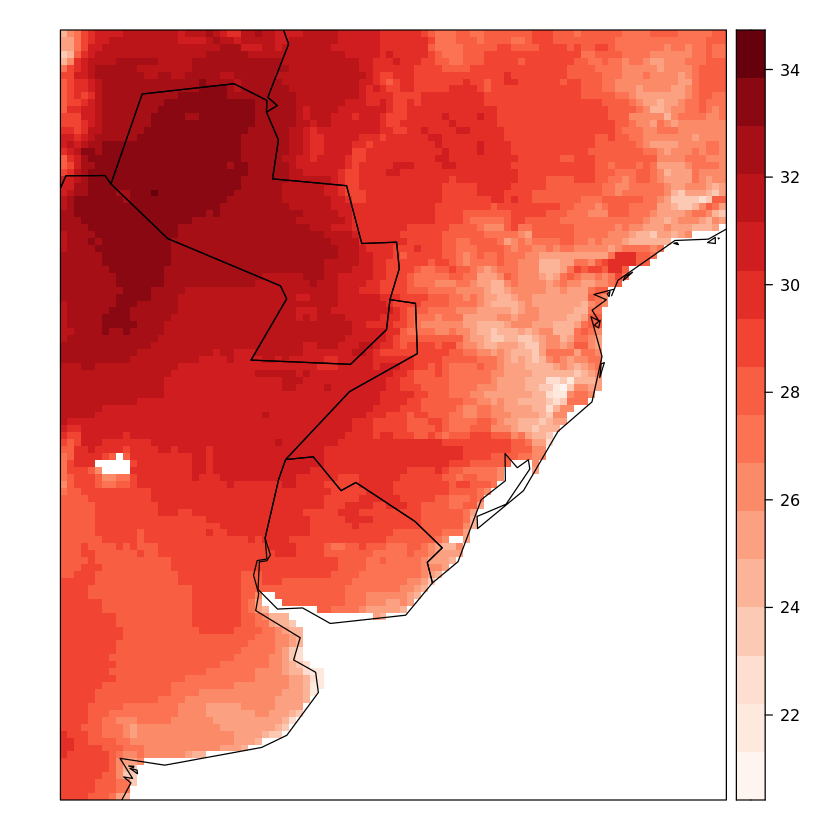

In [17]:
spatialPlot(climatology(t2max_MSWX_02_masked), backdrop.theme = "countries", color.theme = 'Reds')

In [18]:
# This common grid is later used to interpolate all model simulations.
grid_MSWX <- getGrid(t2max_MSWX_02)
save(grid_MSWX, file = file.path(output_dir, "grid_MSWX_02.rda"))
save(t2max_MSWX_02_masked,  file = file.path(output_dir, "Data_CV_BA_tasmax_MSWX.rda"))
invisible(gc())

In [19]:
huss_MSWX <- loadGridData(dataset = mswx_huss_file,var = "specific_humidity",  lonLim = sesa_limits[["lon"]],
  latLim = sesa_limits[["lat"]],  years = years,  season = summer_months)

huss_MSWX_02 <- upscaleGrid(huss_MSWX,  times = 2,aggr.fun = list(FUN = mean, na.rm = TRUE))%>% redim(drop=T)
huss_MSWX_02=fix_grid_mswx(huss_MSWX_02)

[2026-09-09 15:41:48] Defining geo-location parameters

[2026-09-09 15:41:48] Defining time selection parameters

[2026-09-09 15:41:48] Retrieving data subset ...

[2026-09-09 15:42:00] Done



In [20]:
huss_MSWX_02=subsetGrid(huss_MSWX_02,lonLim = sesa_lon) #adjust to SESA region
huss_MSWX_02_masked=apply_landmask(huss_MSWX_02,mask_MSXW)

In [21]:
save(huss_MSWX_02_masked,file = file.path(output_dir, "Data_CV_BA_huss_MSWX.rda"))
rm(huss_MSWX)
invisible(gc())

[2026-09-09 15:52:49] - Computing climatology...

[2026-09-09 15:52:49] - Done.



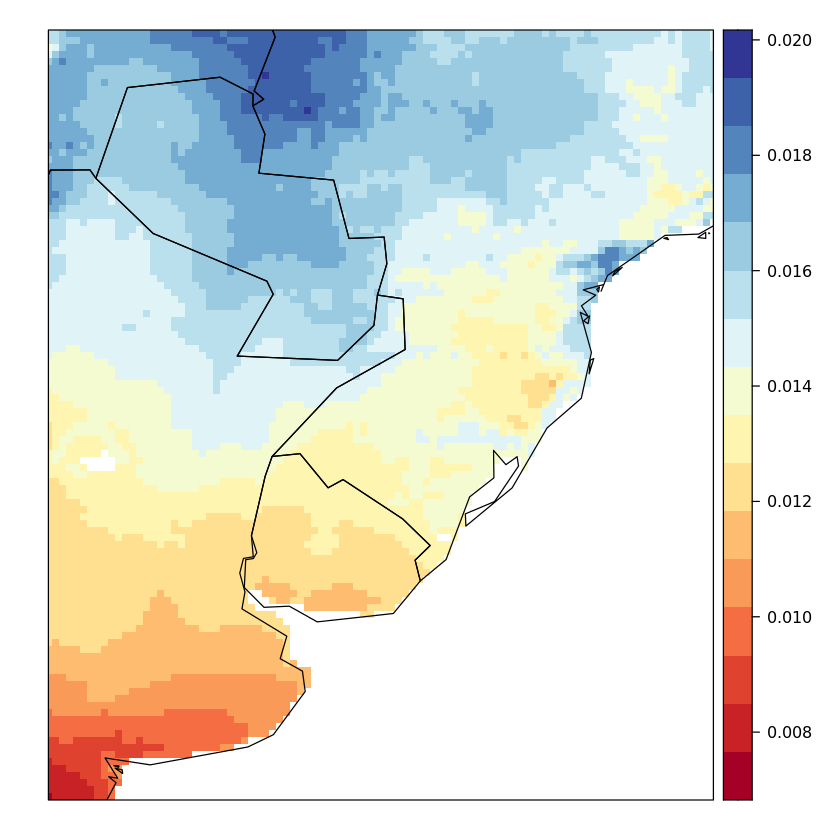

In [22]:
spatialPlot(climatology(huss_MSWX_02_masked),backdrop.theme = 'countries',ylim=sesa_lat,xlim=sesa_lon)

##  CORDEX regional climate model data

CORDEX-CORE simulations (including REMO2015 and RegCM4-7) can be accessed through the climate4R Repository. The example below uses REMO2015 driven by NCC-NorESM1-M. 

In [4]:
inventory <- read.csv(  "https://data.meteo.unican.es/inventory.csv",  stringsAsFactors = FALSE)

sam22_inventory <- subset( inventory,  activity == "CORDEX" & domain == "SAM-22")

data.frame(models = sort(unique(sam22_inventory[["model"]])),  row.names = NULL)
sort(unique(sam22_inventory[["rcm"]]))
sort(unique(sam22_inventory[["variable"]]))

models
<fct>
ECMWF-ERAINT
MOHC-HadGEM2-ES
MPI-M-MPI-ESM-LR
MPI-M-MPI-ESM-MR
NCC-NorESM1-M


[1] "RegCM4-7" "REMO2015"

[1] "huss"    "orog"    "pr"      "sfcWind" "sftlf"   "tas"     "tasmax" 
[8] "tasmin"

In [5]:
# CORDEX example identifiers
target_rcm <- "REMO2015"
target_gcm <- "NCC-NorESM1-M"
target_experiment <- "historical"
target_variable <- "tasmax"

In [6]:
model_entry <- select_inventory_row(  inventory = inventory,  variable = target_variable,  rcm = target_rcm,
  model = target_gcm,  experiment = target_experiment)

model_entry[, intersect(c("model", "rcm", "experiment", "variable", "location"), names(model_entry))]
entry_id <- 1L

,model,rcm,experiment,variable,location
,<chr>,<chr>,<chr>,<chr>,<chr>
33970,NCC-NorESM1-M,REMO2015,historical,tasmax,https://data.meteo.unican.es/thredds/dodsC/esgf/replica/temporal/CORDEX/output/SAM-22/GERICS/NCC-NorESM1-M/historical/r1i1p1/REMO2015/v1/day/v20191015/CORDEX_output_SAM-22_GERICS_NCC-NorESM1-M_historical_r1i1p1_REMO2015_v1_day_tasmax_v20191015.ncml


In [7]:
model_data <- loadGridData( dataset = as.character(model_entry[["location"]]),var = target_variable,
  years = years, season = summer_months)

[2026-09-09 17:51:28.370243] Opening dataset...

[2026-09-09 17:51:30.165198] The dataset was successfuly opened

[2026-09-09 17:51:30.170503] Defining geo-location parameters

[2026-09-09 17:51:30.541055] Defining time selection parameters

[2026-09-09 17:51:30.709062] Retrieving data subset ...

[2026-09-09 17:52:30.951844] Done



In [8]:
# Land fraction 
mask_entry <- select_inventory_row( inventory = inventory, variable = "sftlf", rcm = target_rcm, model = target_gcm,
  experiment = target_experiment)
land_mask <- prepare_landmask(mask_file = as.character(mask_entry[["location"]][1]), threshold = 50) %>% redim(drop = FALSE)
model_data <- apply_landmask(model_data, land_mask)

[2026-09-09 17:52:34.393775] Opening dataset...

[2026-09-09 17:52:34.71306] The dataset was successfuly opened

[2026-09-09 17:52:34.716422] Defining geo-location parameters

[2026-09-09 17:52:34.978769] Defining time selection parameters

NOTE: Undefined Dataset Time Axis (static variable)

[2026-09-09 17:52:34.9861] Retrieving data subset ...

[2026-09-09 17:52:35.1351] Done



In [9]:
load(file.path(output_dir, "grid_MSWX_02.rda")) #load MSWX grid data

In [10]:
#interpolate model data to MSWX grid using MSWX grid save previously
#load(file.path(output_dir, "grid_MSWX_02.rda"))
model_interpolated <- interpGrid(grid = model_data,  new.coordinates = grid_MSWX)

[2026-09-09 17:54:38.206213] Calculating nearest neighbors...

[2026-09-09 17:54:59.378344] Performing nearest interpolation... may take a while

[2026-09-09 17:55:00.41241] Done



[2026-09-09 17:55:09.84881] Calculating nearest neighbors...

[2026-09-09 17:55:30.03982] Performing nearest interpolation... may take a while

[2026-09-09 17:55:31.061519] Done

[2026-09-09 17:55:33.681531] - Computing climatology...

[2026-09-09 17:55:34.015435] - Done.



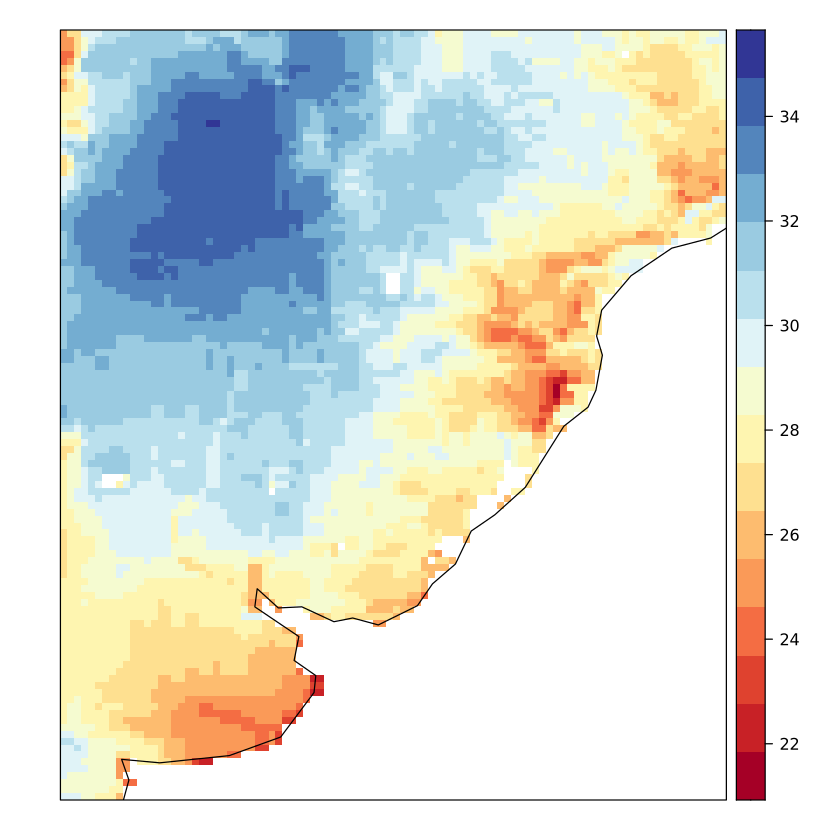

In [11]:
# Interpolate first to guarantee the same grid in every dataset.
model_interpolated <- interpGrid(grid = model_data,  new.coordinates = grid_MSWX)

# Convert temperature from kelvin to degrees Celsius.
if (target_variable %in% c("tas", "tasmax")) {
  model_interpolated <- gridArithmetics(model_interpolated, 273.15, operator = "-")
}

spatialPlot(climatology(model_interpolated), backdrop.theme = "coastline")

In [12]:
simulation_id <- paste(target_variable, target_rcm, target_gcm, sep = "_")

obj_name <- paste0("model_SESA_", target_variable)
assign(obj_name,  model_interpolated)

save(list = obj_name,  file = file.path(output_dir, paste0("Data_", simulation_id, ".rda")))

rm(model_data, model_interpolated, land_mask)
invisible(gc())

In [13]:
target_rcm <- "REMO2015"
target_gcm <- "NCC-NorESM1-M"
target_experiment <- "historical"
target_variable <- "huss"

In [14]:
model_entry <- select_inventory_row(  inventory = inventory,  variable = target_variable,  rcm = target_rcm,
  model = target_gcm,  experiment = target_experiment)


model_entry[, intersect(c("model", "rcm", "experiment", "variable", "location"), names(model_entry))]
entry_id <- 1L

,model,rcm,experiment,variable,location
,<chr>,<chr>,<chr>,<chr>,<chr>
33966,NCC-NorESM1-M,REMO2015,historical,huss,https://data.meteo.unican.es/thredds/dodsC/esgf/replica/temporal/CORDEX/output/SAM-22/GERICS/NCC-NorESM1-M/historical/r1i1p1/REMO2015/v1/day/v20191015/CORDEX_output_SAM-22_GERICS_NCC-NorESM1-M_historical_r1i1p1_REMO2015_v1_day_huss_v20191015.ncml


In [15]:
model_data <- loadGridData(dataset = as.character(model_entry[["location"]][entry_id]),var = target_variable,
  years = years, season = summer_months)

# Land fraction 
mask_entry <- select_inventory_row( inventory = inventory, variable = "sftlf", rcm = target_rcm, model = target_gcm,
  experiment = target_experiment)
land_mask <- prepare_landmask(mask_file = as.character(mask_entry[["location"]][1]), threshold = 50)
model_data <- apply_landmask(model_data, land_mask)

[2026-09-09 17:56:43.2388] Opening dataset...

[2026-09-09 17:56:45.593972] The dataset was successfuly opened

[2026-09-09 17:56:45.597449] Defining geo-location parameters

[2026-09-09 17:56:45.901007] Defining time selection parameters

[2026-09-09 17:56:45.984545] Retrieving data subset ...

[2026-09-09 17:57:49.545855] Done

[2026-09-09 17:57:49.716928] Opening dataset...

[2026-09-09 17:57:50.033011] The dataset was successfuly opened

[2026-09-09 17:57:50.036539] Defining geo-location parameters

[2026-09-09 17:57:50.314707] Defining time selection parameters

NOTE: Undefined Dataset Time Axis (static variable)

[2026-09-09 17:57:50.321542] Retrieving data subset ...

[2026-09-09 17:57:50.451107] Done



[2026-09-09 18:00:18.11878] Calculating nearest neighbors...

[2026-09-09 18:00:37.442263] Performing nearest interpolation... may take a while

[2026-09-09 18:00:38.496246] Done

[2026-09-09 18:00:38.7308] - Computing climatology...

[2026-09-09 18:00:39.07099] - Done.



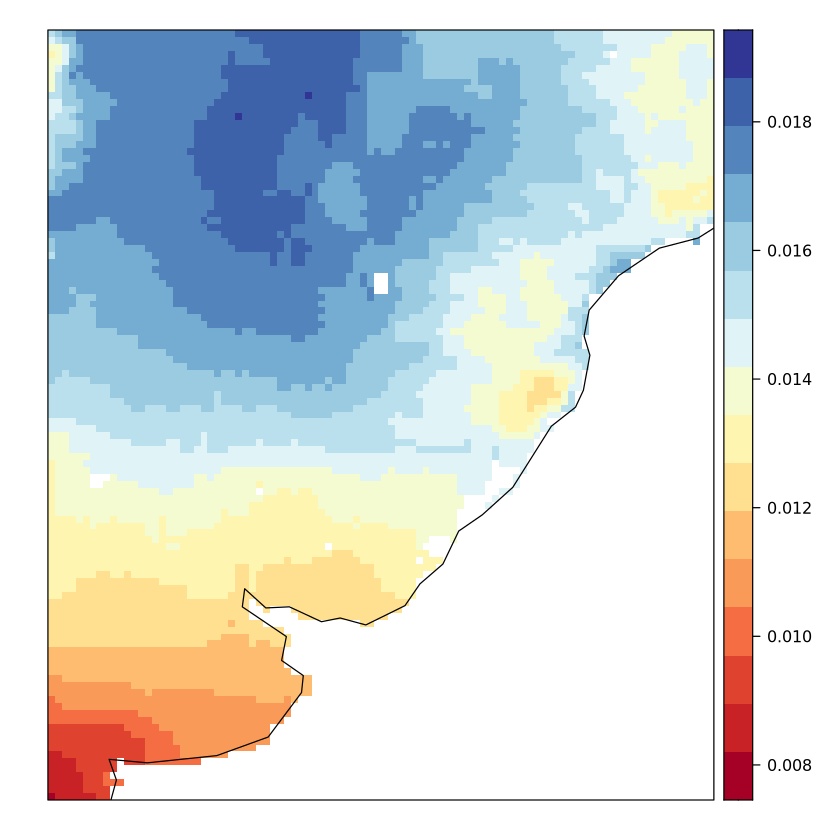

In [16]:
# Interpolate first to guarantee exactly the same grid in every dataset.
model_interpolated <- interpGrid(grid = model_data,  new.coordinates = grid_MSWX)

spatialPlot(climatology(model_interpolated), 
backdrop.theme = "coastline")

In [17]:
simulation_id <- paste(target_variable, target_rcm, target_gcm, sep = "_")

obj_name <- paste0("model_SESA_", target_variable)
assign(obj_name,  model_interpolated)

save(list = obj_name,  file = file.path(output_dir, paste0("Data_", simulation_id, ".rda")))

rm(model_data, model_interpolated, land_mask)
invisible(gc())

In [7]:
sessionInfo()

R version 3.6.3 (2020-02-29)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 18.04.6 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.7.1
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.7.1

locale:
 [1] LC_CTYPE=es_AR.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=es_AR.UTF-8           LC_COLLATE=es_AR.UTF-8       
 [5] LC_MONETARY=es_AR.UTF-8       LC_MESSAGES=es_AR.UTF-8      
 [7] LC_PAPER=es_AR.UTF-8          LC_NAME=es_AR.UTF-8          
 [9] LC_ADDRESS=es_AR.UTF-8        LC_TELEPHONE=es_AR.UTF-8     
[11] LC_MEASUREMENT=es_AR.UTF-8    LC_IDENTIFICATION=es_AR.UTF-8

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] magrittr_2.0.3      visualizeR_1.6.1    transformeR_2.1.2  
[4] loadeR_1.7.1        climate4R.UDG_0.2.3 loadeR.java_1.1.1  
[7] rJava_1.0-6        

loaded via a namespace (and not attached):
 [1] viridis_0.6.2           maps_3.